### Ejericicio Clustering 1

Suponer que representamos cada cluster de puntos de dos coordenadas numéricas mediante listas (o arrays).
Definir una función que, dado un cluster y dado un punto adicional (con 2 coordenadas), determine cuál punto del cluster ese el más cercano.


- Sabemos que un cluster es un grupo de puntos o puntos en un eje de coordenadas
- Crear una función que reciba un punto (2, 7) y en base a un cluster de puntos, determinar que punto es el más cercano

#### Input

$$
[
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9)
]
$$

$$(4.0, 5.0)$$

#### Output

$$(4.5, 5.8)$$


In [1]:
import math


def dis_euclidiana(punto_a, punto_b):

    if punto_a is None or punto_b is None:
        print("La función debe recibir un punto A y B")
        return

    a_x = punto_a[0]
    a_y = punto_a[1]

    b_x = punto_b[0]
    b_y = punto_b[1]

    distancia = math.sqrt(((a_x - b_x) ** 2) + ((a_y - b_y) ** 2))

    return distancia

In [2]:
def obtener_punto_cercano_en_cluster(cluster, ref_punto):

    if cluster is None or ref_punto is None:
        print("La función debe recibir un cluster y un punto de referencia")
        return

    punto_min = cluster[0]
    for punto in cluster:
        if dis_euclidiana(punto, ref_punto) < dis_euclidiana(punto_min, ref_punto):
            punto_min = punto

    return punto_min


cluster = [
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9),
]

ref_punto = (8.8, 9)

punto_mas_cercano = obtener_punto_cercano_en_cluster(cluster, ref_punto)

punto_mas_cercano

(8.7, 9.2)

#### Calcular Centroide Cluster


In [3]:
cluster = [(1.2, 2.3), (4.5, 6.7), (7.8, 9.1)]

prom_x = sum(punto[0] for punto in cluster) / len(cluster)
prom_y = sum(punto[1] for punto in cluster) / len(cluster)

centroide = (prom_x, prom_y)

centroide

(4.5, 6.033333333333334)

# Ejericicio Clustering 2

Calcular dado un cluster, su radio y su diametro

Input

$$
[
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9)
]
$$

Output
$$Radio: 5.0$$
$$Diametro: 10.0$$


In [4]:
cluster = [
    (0.2, 9.8),
    (15.3, -4.2),
    (-7.5, 3.1),
    (22.0, 18.4),
    (-12.7, -9.6),
    (5.5, 25.3),
    (-18.9, 14.2),
    (30.1, -20.5),
    (8.8, -15.7),
    (-25.0, 5.0),
]

#### Calcular Centroide

centroide = (promedio_x, promedio_y)


In [5]:
def calcular_centroide(cluster):
    prom_x = sum(punto[0] for punto in cluster) / len(cluster)
    prom_y = sum(punto[1] for punto in cluster) / len(cluster)

    return prom_x, prom_y

In [6]:
import math


def calcular_dis_euclidiana(punto_a, punto_b):
    a_x = punto_a[0]
    a_y = punto_a[1]

    b_x = punto_b[0]
    b_y = punto_b[1]
    distancia = math.sqrt(((a_x - b_x) ** 2) + ((a_y - b_y) ** 2))

    return distancia

#### Calcular radio

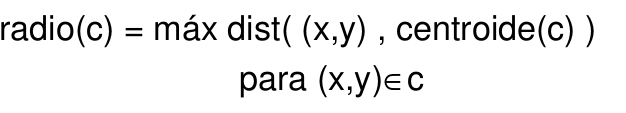

El radio de un clusters es la máxima distancia de los puntos del cluster a su centroide


In [7]:
def calcular_radio(cluster):
    centroide = calcular_centroide(cluster)

    dis_max = 0
    for x, y in cluster:
        distancia_actual = calcular_dis_euclidiana((x, y), centroide)

        if distancia_actual > dis_max:
            dis_max = distancia_actual

    radio = dis_max

    return radio

#### Calcular diametro

El diámetro de un cluster es la máxima distancia entre un par de puntos del cluster.

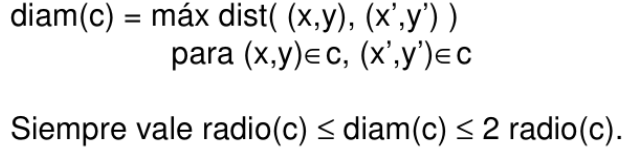


In [8]:
def calcular_diametro(cluster):
    dis_max = 0
    for i in range(len(cluster)):
        for j in range(i + 1, len(cluster)):
            distancia = calcular_dis_euclidiana(cluster[i], cluster[j])

            if distancia > dis_max:
                dis_max = distancia

    diametro = dis_max

    return diametro

print(calcular_diametro(cluster))

60.714578150556235


#### Calcular radio y diametro


In [9]:
diametro = calcular_diametro(cluster)
radio = calcular_radio(cluster)


print("Cluster", cluster)
print("Diametro", diametro)
print("Radio", radio)

Cluster [(0.2, 9.8), (15.3, -4.2), (-7.5, 3.1), (22.0, 18.4), (-12.7, -9.6), (5.5, 25.3), (-18.9, 14.2), (30.1, -20.5), (8.8, -15.7), (-25.0, 5.0)]
Diametro 60.714578150556235
Radio 36.533666665146


#### Graficando clusters

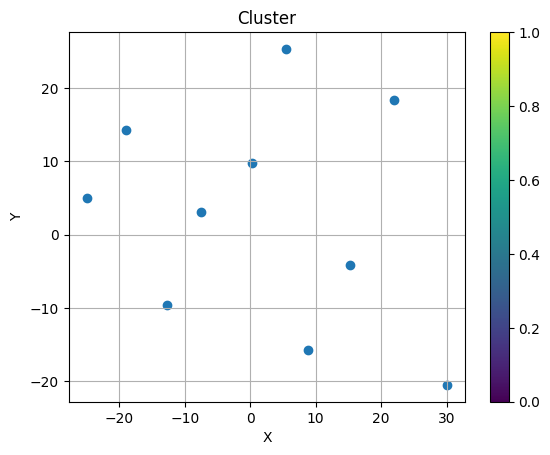

In [10]:
import matplotlib.pyplot as plt

x = [punto[0] for punto in cluster]
y = [punto[1] for punto in cluster]

plt.scatter(x, y)
plt.colorbar()
plt.title("Cluster")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

#### Usando Pandas

In [21]:
import pandas as pd

df = pd.read_csv("data.csv")

df = df.drop(columns=["id"])

df.head()

,latitude,longitude
0,-12.45,130.84
1,48.85,2.35
2,-33.87,151.21
3,35.68,139.69
4,55.75,37.62


#### K-means clustering

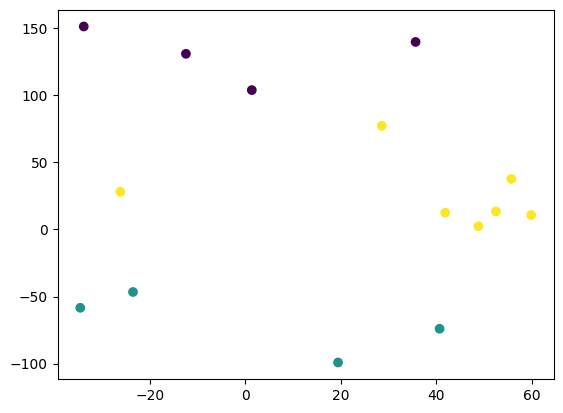

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

kmeans.fit(df)

plt.scatter(df["latitude"], df["longitude"], c=kmeans.labels_)
plt.show()

### Ejercicio 3

Escribir un script que (sobre un ejemplo como el anterior) calcule KMeans con distintos valores de k (n_clusters) desde un mínimo hasta un máximo, y determine el mejor k, en el sentido de que sea mínima la varianza entre los diámetros de los clusters obtenidos.

Input:
$$Dataframe$$
Output:
$$kmeans$$

In [ ]:
def calc_kmeans(df):
    